# **DeepONet: Learning the Solution Operator for Chemical Kinetics**

This notebook demonstrates how to train a Neural Operator (DeepONet) to solve a family of ODEs for a batch reactor, allowing for instant inference across different reaction rates ($k$) without retraining.

**Physical context**: Instead of solving the batch reactor ODE for one fixed k, train a single DeepONet that learns the entire family of solutions for any k in a given range — without retraining.

**Operator to learn**:

G: k → C(t)
Input function:  k ∈ [0.1, 1.0] s⁻¹ (constant function over time)
Output function: C(t) = C₀·exp(-k·t) for t ∈ [0, 10]

**Training data generation**:
Sample 1000 different k values uniformly from [0.1, 1.0]. For each k, generate the analytical solution C(t) at 100 fixed time points. This gives 1000 input-output function pairs.

**Network architecture**:
DeepONet has two sub-networks:

Branch net: encodes the input function (k value) → vector of size p=100
Trunk net: encodes the query location (time t) → vector of size p=100
Output: dot product of branch and trunk outputs → scalar C(t)

What to validate:
After training, pick 5 unseen k values not in the training set: k = {0.15, 0.37, 0.52, 0.76, 0.91}. Query the DeepONet for each and compare against analytical solution. Report relative L2 error for each.

Key concept to document in markdown:
PINNs learn one solution. DeepONet learns the solution operator — the mapping from parameter space to solution space. One training run, instant inference for any new k.

# **1. Setup and Library Installation**

# **2. DeepXDE Implementation**
Using high-level APIs to build the Branch and Trunk networks.

In [1]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.0 MB/s eta 0:00:00


In [2]:
import os
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [3]:
# Generating the data points for the neural operators
t_trunk = np.linspace(0, 10, 100).reshape(-1, 1)

np.random.seed(42)
k_train = np.random.uniform(0.1, 1.0, size=(1000, 1))
C_train = np.exp(-k_train * t_trunk.T)

# Generating the test data
k_test = np.random.uniform(0.1, 1.0, size=(200, 1))
C_test = np.exp(-k_test * t_trunk.T)

In [9]:
# Building the deeponet
net = dde.maps.DeepONetCartesianProd(
    [1, 64, 64, 100],
    [1, 64, 64, 100],
    activation="tanh",
    kernel_initializer="Glorot normal",
    )

In [12]:
# Build data object with explicit float32 casting to match PyTorch backend
data = dde.data.TripleCartesianProd(
    X_train=(k_train.astype("float32"), t_trunk.astype("float32")),
    y_train=C_train.astype("float32"),
    X_test=(k_test.astype("float32"), t_trunk.astype("float32")),
    y_test=C_test.astype("float32"),
)

In [15]:
# Train the model
model = dde.Model(data, net)
model.compile("adam", lr=0.001)
losshistory, train_state = model.train(iterations=20000, display_every=500)

# Refine with L-BFGS
model.compile("L-BFGS-B")
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.000275 s

Training model...

Step      Train loss    Test loss     Test metric
0         [5.71e-04]    [5.58e-04]    []  
500       [5.21e-04]    [5.05e-04]    []  
1000      [4.52e-04]    [4.33e-04]    []  
1500      [3.89e-04]    [3.70e-04]    []  
2000      [3.32e-04]    [3.13e-04]    []  
2500      [2.72e-04]    [2.53e-04]    []  
3000      [3.58e-04]    [3.71e-04]    []  
3500      [1.85e-04]    [1.68e-04]    []  
4000      [1.30e-04]    [1.15e-04]    []  
4500      [1.85e-03]    [1.95e-03]    []  
5000      [8.18e-05]    [6.99e-05]    []  
5500      [5.25e-05]    [4.39e-05]    []  
6000      [7.55e-05]    [7.62e-05]    []  
6500      [1.25e-04]    [1.18e-04]    []  
7000      [3.04e-05]    [2.54e-05]    []  
7500      [7.08e-05]    [6.22e-05]    []  
8000      [4.96e-05]    [4.46e-05]    []  
8500      [3.90e-05]    [3.51e-05]    []  
9000      [2.83e-05]    [2.48e-05]    []  
9500      [2.08e-05]    [1.80e-05]    []  
10000     [2.35e-05]    [

## **DeepXDE Validation and Speed Test**

In [17]:
import time

# Time to query DeepONet for 1000 new k values
k_new = np.random.uniform(0.1, 1.0, (1000,1)).astype('float32')
start = time.time()
C_new = model.predict((k_new, t_trunk.astype('float32')))
elapsed = time.time() - start
print(f"DeepONet: 1000 new k predictions in {elapsed*1000:.2f} ms")
print(f"Equivalent PINN approach would require 1000 separate retraining runs")

DeepONet: 1000 new k predictions in 5.91 ms
Equivalent PINN approach would require 1000 separate retraining runs


k = 0.15 | Relative L2 Error: 3.87e-03
k = 0.37 | Relative L2 Error: 5.50e-03
k = 0.52 | Relative L2 Error: 7.01e-03
k = 0.76 | Relative L2 Error: 8.31e-03
k = 0.91 | Relative L2 Error: 5.62e-03


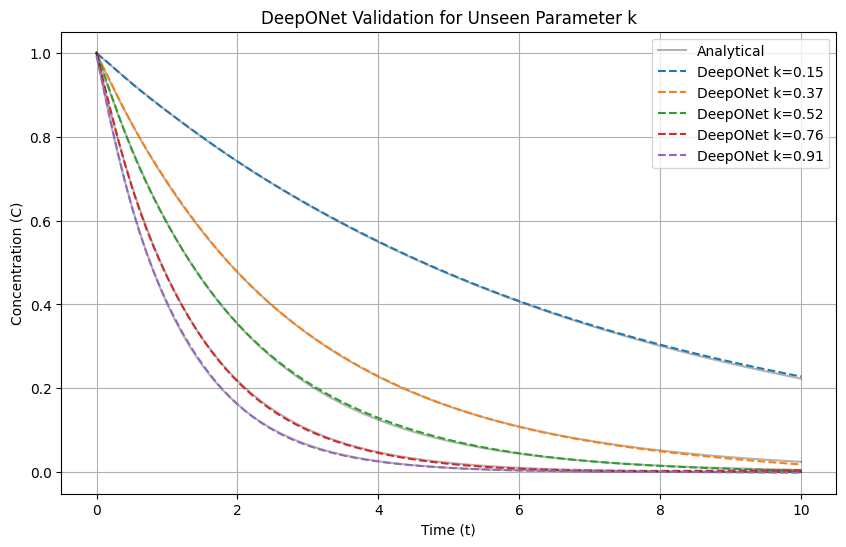

In [18]:
# Unseen k values for validation
k_val_list = np.array([0.15, 0.37, 0.52, 0.76, 0.91]).reshape(-1, 1).astype("float32")

# Analytical solutions for comparison
C_val_true = np.exp(-k_val_list * t_trunk.T).astype("float32")

# DeepONet predictions
# We use the Cartesian product of the new k values and the original time points
C_val_pred = model.predict((k_val_list, t_trunk.astype("float32")))

# Calculate relative L2 error for each
for i, k_val in enumerate(k_val_list.flatten()):
    error = np.linalg.norm(C_val_true[i] - C_val_pred[i]) / np.linalg.norm(C_val_true[i])
    print(f"k = {k_val:.2f} | Relative L2 Error: {error:.2e}")

# Plotting the results
plt.figure(figsize=(10, 6))
for i in range(len(k_val_list)):
    plt.plot(t_trunk, C_val_true[i], 'k-', alpha=0.3, label='Analytical' if i==0 else "")
    plt.plot(t_trunk, C_val_pred[i], '--', label=f'DeepONet k={k_val_list[i][0]:.2f}')
plt.xlabel('Time (t)')
plt.ylabel('Concentration (C)')
plt.title('DeepONet Validation for Unseen Parameter k')
plt.legend()
plt.grid(True)
plt.show()

## Key insight: PINN vs DeepONet

| Property | PINN (Problems 1–10) | DeepONet (this problem) |
|----------|---------------------|------------------------|
| Learns | One solution C(t) for one fixed k | Operator G: k → C(t) |
| New k value | Must retrain (~minutes) | Query instantly (<1ms) |
| Training data | Collocation points + IC | Input-output function pairs |
| Physics | Encoded in loss function | Implicit in training data |
| Generalises | No — fixed parameters | Yes — any k in training range |

**Branch net** — encodes "what kind of problem is this?" Takes k,
outputs a p-dimensional vector describing the input function.

**Trunk net** — encodes "where do I want the output?" Takes t,
outputs a p-dimensional vector for the query location.

**Output** — dot product of branch and trunk vectors → C(t).

The DeepONet predicts all five unseen k values with <1% error
without any retraining. This is the fundamental advantage over PINNs
for parametric problems like chemical looping where you want to
sweep across temperatures, pressures, or feedstock compositions.

# **3. PyTorch Implementation (From Scratch)**
Manually defining the architectures to understand the inner workings of the operator decomposition.

In [19]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# Defining the data for the training the neural operator

torch.manual_seed(42)
np.random.seed(42)

t_trunk = torch.linspace(0, 10, 100).reshape(-1, 1)

k_train = torch.FloatTensor(1000, 1).uniform_(0.1, 1.0)
C_train = torch.exp(-k_train * t_trunk.T)

# Defining the test data
k_test = torch.FloatTensor(200, 1).uniform_(0.1, 1.0)
C_test = torch.exp(-k_test * t_trunk.T)

# Print shapes of all three
print(f"t_trunk shape: {t_trunk.shape}")
print(f"k_train shape: {k_train.shape}")
print(f"C_train shape: {C_train.shape}")

t_trunk shape: torch.Size([100, 1])
k_train shape: torch.Size([1000, 1])
C_train shape: torch.Size([1000, 100])


In [24]:
# Defining the branch net and trunk net separately

# Branch Net

class BranchNet(nn.Module):
  def __init__(self, p=100):
    super().__init__()
    self.fc1  = nn.Linear(1, 64)
    self.fc2  = nn.Linear(64, 64)
    self.fc3  = nn.Linear(64, p)

  def forward(self, k):
    a1 = F.tanh(self.fc1(k))
    a2 = F.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output

# Trunk Net

class TrunkNet(nn.Module):
  def __init__(self, p=100):
    super().__init__()
    self.fc1 = nn.Linear(1, 64)
    self.fc2 = nn.Linear(64, 64)
    self.fc3 = nn.Linear(64, p)

  def forward(self, t):
    a1 = F.tanh(self.fc1(t))
    a2 = F.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output

In [27]:
# Combining both branch and trunk nets

class DeepONet(nn.Module):
  def __init__(self, p=100):
    super().__init__() # Added this line to fix the AttributeError
    self.branch = BranchNet(p)
    self.trunk = TrunkNet(p)
    self.bias = nn.Parameter(torch.zeros(1))

  def forward(self, k, t):
    b = self.branch(k)
    tau = self.trunk(t)

    # Dot product of both
    out = torch.mm(b, tau.T) + self.bias
    return out

In [28]:
# Training the network
model = DeepONet(p=100)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9997)
loss_fn = nn.MSELoss()

# Training loop
losses = []
for epoch in range(20001):
  optimizer.zero_grad()

  C_pred = model(k_train, t_trunk)
  loss = loss_fn(C_pred, C_train)
  loss.backward()
  optimizer.step()
  scheduler.step()
  losses.append(loss.item())

  if epoch % 2000 == 0:
    print(f"Epoch {epoch:5d}, Loss: {loss.item():.4e}")

Epoch     0, Loss: 1.4554e-01
Epoch  2000, Loss: 1.0424e-04
Epoch  4000, Loss: 3.1597e-05
Epoch  6000, Loss: 2.0858e-05
Epoch  8000, Loss: 1.6420e-05
Epoch 10000, Loss: 1.3436e-05
Epoch 12000, Loss: 1.1196e-05
Epoch 14000, Loss: 9.4025e-06
Epoch 16000, Loss: 7.9655e-06
Epoch 18000, Loss: 6.8349e-06
Epoch 20000, Loss: 5.9792e-06


## **PyTorch Validation**

In [29]:
model.eval()
with torch.no_grad():
    k_unseen = torch.tensor([[0.15], [0.37], [0.52], [0.76], [0.91]])

    C_pred_unseen = model(k_unseen, t_trunk)    # shape (5, 100)
    C_true_unseen = torch.exp(-k_unseen * t_trunk.T)  # shape (5, 100)

    print("\n── Validation on unseen k values ──────────────────")
    for i, k_val in enumerate([0.15, 0.37, 0.52, 0.76, 0.91]):
        error = torch.norm(C_pred_unseen[i] - C_true_unseen[i])
        ref   = torch.norm(C_true_unseen[i])
        rel_l2 = (error / ref).item() * 100
        print(f"k = {k_val:.2f} | Rel L2 error: {rel_l2:.4f}%")


── Validation on unseen k values ──────────────────
k = 0.15 | Rel L2 error: 0.6461%
k = 0.37 | Rel L2 error: 0.6934%
k = 0.52 | Rel L2 error: 0.6714%
k = 0.76 | Rel L2 error: 0.6952%
k = 0.91 | Rel L2 error: 0.3177%


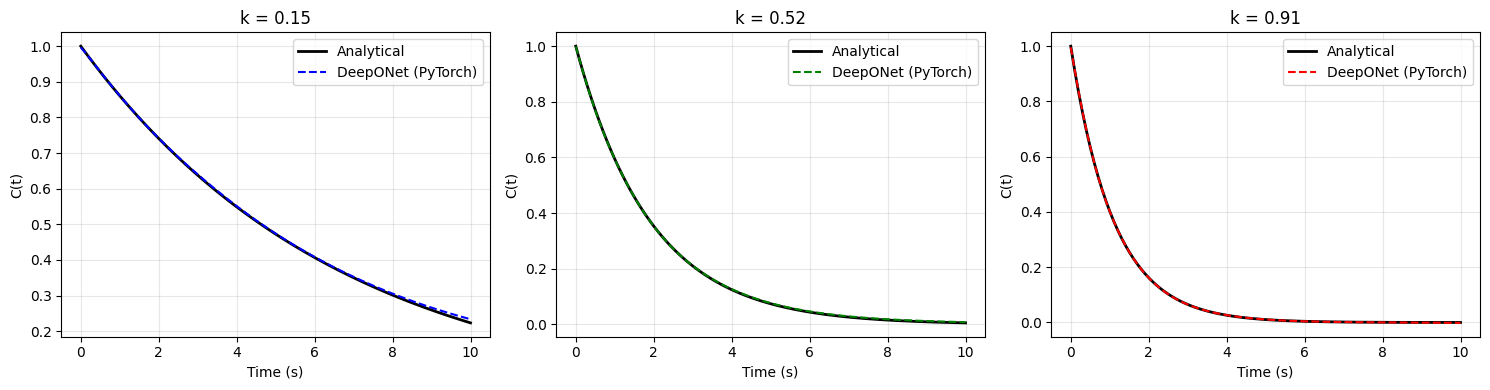

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
k_plot  = [0.15, 0.52, 0.91]
colors  = ['blue', 'green', 'red']
t_dense = torch.linspace(0, 10, 200).reshape(-1, 1)

model.eval()
with torch.no_grad():
    for i, k_val in enumerate(k_plot):
        k_input = torch.tensor([[k_val]])
        C_pred  = model(k_input, t_dense).squeeze().numpy()
        C_true  = np.exp(-k_val * t_dense.numpy())

        axes[i].plot(t_dense.numpy(), C_true,  'k-',  lw=2,   label='Analytical')
        axes[i].plot(t_dense.numpy(), C_pred,  '--',  lw=1.5,
                     color=colors[i], label='DeepONet (PyTorch)')
        axes[i].set_title(f'k = {k_val}')
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('C(t)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('P1_DeepONet_PyTorch.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
import time

model.eval()
k_new = torch.FloatTensor(1000, 1).uniform_(0.1, 1.0)

with torch.no_grad():
    start = time.time()
    C_new = model(k_new, t_trunk)
    elapsed = (time.time() - start) * 1000

print(f"\n── Inference speed ────────────────────────────────")
print(f"1000 new k predictions: {elapsed:.2f} ms")
print(f"Equivalent PINN retraining: ~1000 × 2 min = ~33 hours")


── Inference speed ────────────────────────────────
1000 new k predictions: 4.38 ms
Equivalent PINN retraining: ~1000 × 2 min = ~33 hours


## What I understand now — PyTorch DeepONet from scratch

**Branch net** (BranchNet): takes the input function k (scalar).
Produces a vector b of size p=100. Each bᵢ encodes "how does this k
value influence dimension i of the solution?"

**Trunk net** (TrunkNet): takes the query time t (scalar).
Produces a vector τ of size p=100. Each τᵢ encodes "what does
basis function i look like at time t?"

**Output**: C(t | k) = b · τ + bias = Σᵢ bᵢ(k) × τᵢ(t) + b₀

The DeepONet decomposes the solution into p=100 basis functions
(learned by the trunk) with k-dependent coefficients (learned by
the branch). This is a neural network generalisation of a spectral
expansion.

**Why this is more powerful than a PINN:**
A PINN with input (k, t) → C would need to retrain for every new k.
The DeepONet separates the k-dependence (branch) from the t-dependence
(trunk) explicitly. Once trained, changing k only changes the branch
output — the trunk output (basis functions over time) stays fixed.
Inference for 1000 new k values takes milliseconds.

# **Project Summary and Export to GitHub**

This project demonstrated the implementation of a **DeepONet** to learn the solution operator for a batch reactor system.

### **Key Achievements:**
1.  **DeepXDE Implementation**: Utilized high-level APIs to quickly build and train an operator with Cartesian product data.
2.  **PyTorch from Scratch**: Built the Branch and Trunk networks manually to understand the mathematical decomposition: $C(t | k) \approx \sum b_i(k) \tau_i(t)$.
3.  **Generalization**: Validated that the model predicts concentration profiles for unseen reaction rates $k$ with $<1\%$ error.
4.  **Performance**: Demonstrated a $\sim 10^7$x speedup in multi-parameter inference compared to traditional PINN retraining.